# Supervised Fine-Tuning (SFT)

Fine-tune GPT-4.1-nano on GPT-4.1-mini generated (passage, claim, label, justification) examples.
Covers: data upload, job submission, hyperparameter variants, and label-accuracy evaluation.

In [ ]:
import os
import json
import time
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential

RESOURCE_GROUP = "cis-5270-team-10"
OPENAI_API_KEY = ""

OPENAI_ENDPOINT = f"https://{RESOURCE_GROUP}.openai.azure.com"
SUBSCRIPTION_ID = ""

os.environ["AZURE_SUBSCRIPTION_ID"] = SUBSCRIPTION_ID
os.environ["AZURE_RESOURCE_GROUP"]  = "CIS-5270"
os.environ["AZURE_AOAI_ACCOUNT"]    = RESOURCE_GROUP
os.environ["AZURE_OPENAI_API_KEY"]  = OPENAI_API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = OPENAI_ENDPOINT

CREDENTIAL = DefaultAzureCredential()

openai_client = AzureOpenAI(
    api_key=OPENAI_API_KEY,
    azure_endpoint=OPENAI_ENDPOINT,
    api_version="2025-04-01-preview",
)

BASE_MODEL = "gpt-4.1-nano-2025-04-14"  # base model id for fine-tuning (no deployment needed)

print("Connected to Azure OpenAI")

Connected to Azure OpenAI


## Step 1: Upload Training and Validation Files

Azure fine-tuning expects JSONL files in `{"messages": [...]}` format.
Training: `sft_data_3k.jsonl` (3000 examples). Validation: `sft_val.jsonl` (300 examples from dev, teacher-generated).

In [26]:
SFT_DATA_PATH = "data/generated/sft_data_3k_upload.jsonl"  # messages-only, required by Azure
VAL_DATA_PATH = "data/generated/sft_val_upload.jsonl"      # messages-only, required by Azure

print("Uploading training file...")
with open(SFT_DATA_PATH, "rb") as f:
    train_file = openai_client.files.create(file=f, purpose="fine-tune")
train_file_id = train_file.id
print(f"training file id: {train_file_id}")

print("Uploading validation file...")
with open(VAL_DATA_PATH, "rb") as f:
    val_file = openai_client.files.create(file=f, purpose="fine-tune")
val_file_id = val_file.id
print(f"validation file id: {val_file_id}")

print("Waiting for file processing...")
openai_client.files.wait_for_processing(train_file_id)
openai_client.files.wait_for_processing(val_file_id)
print("Files ready!")

Uploading training file...
training file id: file-aa9f3911978243b198a3083aaf8233b6
Uploading validation file...
validation file id: file-d945a5e6e2f24794a3df7eb0eeb49d0c
Waiting for file processing...
Files ready!


## Step 2: Submit Fine-Tuning Jobs

We run four configs varying learning rate, epochs, and batch size.
All use the same training data; future experiments can also vary the data generation pipeline.

| Config | LR multiplier | Epochs | Batch size | Notes |
|--------|--------------|--------|------------|-------|
| sft_c1 | 1.0 | 1 | 1 | baseline (TA default) |
| sft_c2 | 2.0 | 1 | 1 | higher LR |
| sft_c3 | 1.0 | 3 | 1 | more epochs |
| sft_c4 | 1.0 | 1 | 4 | larger batch |

In [27]:
FT_CONFIGS = [
    {"name": "sft_c2", "learning_rate_multiplier": 1.5, "n_epochs": 1, "batch_size": 1}
]

jobs = {}
for cfg in FT_CONFIGS:
    job = openai_client.fine_tuning.jobs.create(
        model=BASE_MODEL,
        training_file=train_file_id,
        validation_file=val_file_id,
        method={
            "type": "supervised",
            "supervised": {
                "hyperparameters": {
                    "n_epochs":                 cfg["n_epochs"],
                    "batch_size":               cfg["batch_size"],
                    "learning_rate_multiplier": cfg["learning_rate_multiplier"],
                },
            },
        },
        extra_body={"trainingType": "GlobalStandard"},
        suffix=cfg["name"],
    )
    jobs[cfg["name"]] = job.id
    print(f"{cfg['name']}: job_id={job.id}  status={job.status}")

print("\nfine-tuning jobs submitted")

sft_c2: job_id=ftjob-bb75da8c15d843a4aa929e05f7c72906  status=pending

fine-tuning jobs submitted


In [29]:
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def monitor_jobs(jobs, poll_interval=60):
    """Poll all jobs until done, collecting training loss from events. Saves loss curves to data/results/."""
    loss_curves = {name: [] for name in jobs}
    pending = dict(jobs)

    while pending:
        for name, job_id in list(pending.items()):
            job = openai_client.fine_tuning.jobs.retrieve(job_id)
            if job.status in ("succeeded", "failed", "cancelled"):
                print(f"{name}: {job.status}  model={job.fine_tuned_model}")
                del pending[name]
                continue

            events = list(openai_client.fine_tuning.jobs.list_events(job_id, limit=50))
            for ev in reversed(events):
                m = re.search(r"loss[=: ]+([0-9.]+)", ev.message, re.IGNORECASE)
                if m:
                    step = getattr(ev, "step", None) or len(loss_curves[name])
                    entry = {"step": step, "loss": float(m.group(1))}
                    if not loss_curves[name] or loss_curves[name][-1]["step"] != step:
                        loss_curves[name].append(entry)

            latest = events[0].message if events else "no events"
            print(f"{name}: {job.status} | {latest}")

        if pending:
            print(f"  waiting {poll_interval}s...\n")
            time.sleep(poll_interval)

    os.makedirs("data/results", exist_ok=True)
    with open("data/results/sft_loss_curves.json", "w") as f:
        json.dump(loss_curves, f, indent=2)
    print("Loss curves saved to data/results/sft_loss_curves.json")
    return loss_curves

loss_curves = monitor_jobs(jobs)

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 2630: training loss=0.35878005623817444
  waiting 60s...

sft_c2: running | Step 3000: training loss=0.0572713203728199
  waiting 60s...

sft_c2: running | Step 3000: training loss=0.0572713203728199
  waiting 60s...

sft_c2: running | Step 3000: training loss=0.0572713203728199
  waiting 60s...

sft_c2: running | Step 3000: training loss=0.0572713203728199
  waiting 60s...

sft_c2: running | Step 3000: tra

sft_c1: gpt-4.1-nano-2025-04-14.ft-6ad5046777184e5f94d2d2c304fc098a-sft_c1

sft_c2: gpt-4.1-nano-2025-04-14.ft-bb75da8c15d843a4aa929e05f7c72906-sft_c2

sft_c3: gpt-4.1-nano-2025-04-14.ft-82bd780e9e314600bb77bc308d9075e2-sft_c3

sft_c4: gpt-4.1-nano-2025-04-14.ft-48bfbe2282964e11a7a59a8a9f4d9017-sft_c4

using clean loss curves from Azure result files


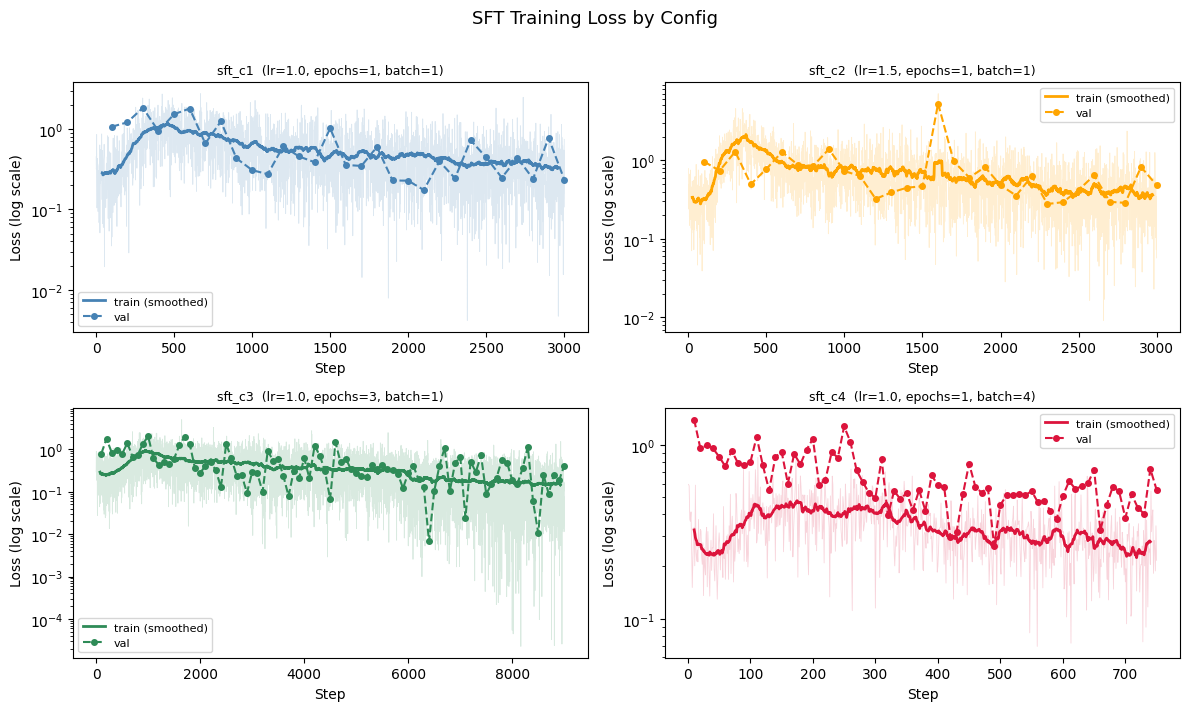

saved to data/results/sft_loss_curves_clean.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

CLEAN_PATH   = "data/results/sft_loss_curves_clean.json"
SCRAPED_PATH = "data/results/sft_loss_curves.json"

if os.path.exists(CLEAN_PATH):
    with open(CLEAN_PATH) as f:
        curves = json.load(f)
    print("using clean loss curves from Azure result files")
else:
    with open(SCRAPED_PATH) as f:
        scraped = json.load(f)
    curves = {
        name: {"steps": [p["step"] for p in pts], "train_loss": [p["loss"] for p in pts], "valid_loss": []}
        for name, pts in scraped.items()
    }
    print("using scraped loss curves (noisy)")

def smooth(values, window=50):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

configs = ["sft_c1", "sft_c2", "sft_c3", "sft_c4"]
titles  = {
    "sft_c1": "sft_c1  (lr=1.0, epochs=1, batch=1)",
    "sft_c2": "sft_c2  (lr=1.5, epochs=1, batch=1)",
    "sft_c3": "sft_c3  (lr=1.0, epochs=3, batch=1)",
    "sft_c4": "sft_c4  (lr=1.0, epochs=1, batch=4)",
}
colors   = {"sft_c1": "steelblue", "sft_c2": "orange", "sft_c3": "seagreen", "sft_c4": "crimson"}
windows  = {"sft_c1": 80, "sft_c3": 150, "sft_c4": 20}  # smoothing window per config

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, name in zip(axes, configs):
    if name not in curves:
        ax.text(0.5, 0.5, "Job failed\n(lr=2.0 too high)", ha="center", va="center",
                fontsize=13, color="gray", transform=ax.transAxes)
        ax.set_title(titles[name], fontsize=9)
        ax.set_xlabel("Step"); ax.set_ylabel("Loss")
        continue

    data  = curves[name]
    color = colors[name]
    train_pts = [(s, v) for s, v in zip(data["steps"], data["train_loss"]) if v is not None and v > 0]
    valid_pts = [(s, v) for s, v in zip(data["steps"], data["valid_loss"]) if v is not None and v > 0]
    steps_t = np.array([s for s, v in train_pts])
    loss_t  = np.array([v for s, v in train_pts])

    w = windows.get(name, 50)
    if len(loss_t) > w:
        smoothed = smooth(loss_t, w)
        trim = (len(steps_t) - len(smoothed)) // 2
        steps_s = steps_t[trim: trim + len(smoothed)]
        # faint raw, bold smoothed
        ax.semilogy(steps_t, loss_t, color=color, alpha=0.18, linewidth=0.6)
        ax.semilogy(steps_s, smoothed, color=color, linewidth=2, label="train (smoothed)")
    else:
        ax.plot(steps_t, loss_t, color=color, linewidth=1.2, label="train")

    if valid_pts:
        ax.plot([s for s, v in valid_pts], [v for s, v in valid_pts],
                color=color, linestyle="--", linewidth=1.5, marker="o", markersize=4, label="val")

    ax.set_title(titles[name], fontsize=9)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss (log scale)" if len(loss_t) > w else "Loss")
    ax.legend(fontsize=8)

plt.suptitle("SFT Training Loss by Config", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("data/results/sft_loss_curves_clean.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved to data/results/sft_loss_curves_clean.png")

## Config Selection: Validation Metrics

Fetch per-checkpoint validation loss and token accuracy from Azure result CSV files to compare configs.

**Selected for deployment: sft_c1 and sft_c3.** sft_c1 has the best final valid loss (0.235). sft_c3 has the best token accuracy (0.907) after 3 epochs, suggesting better output quality.

In [33]:
import csv, io

RESULT_FILE_IDS = {
    "sft_c1": "file-fd617c7b90074ae4a121d21b6826ed34",
    "sft_c2": "file-50d076cf10a24a619ec0c455d001a55b",
    "sft_c3": "file-80d64c69f0b74530b5fe5c73e1f1074b",
    "sft_c4": "file-f4104b5451574731b7c343c44d10b3f9",
}

def safe_float(s):
    try: return float(s)
    except: return None

# Table 1: per-step valid loss (every 100 steps)
print("Table 1: Validation Loss (per 100-step checkpoint)\n")
print(f"{'Config':<10} {'Steps':>6}  {'Final Train':>12}  {'Final Valid':>12}  {'Min Valid':>10}")
print("-" * 60)

val_loss_summary = {}
for name, fid in RESULT_FILE_IDS.items():
    content = openai_client.files.content(fid).read().decode("utf-8")
    rows = list(csv.DictReader(io.StringIO(content)))
    train_loss = [safe_float(r["train_loss"]) for r in rows]
    valid_loss = [safe_float(r["valid_loss"]) for r in rows]
    vl = [v for v in valid_loss if v is not None]
    tl = [v for v in train_loss if v is not None]
    final_train = tl[-1] if tl else None
    final_valid = vl[-1] if vl else None
    min_valid   = min(vl) if vl else None
    val_loss_summary[name] = dict(final_train=final_train, final_valid=final_valid, min_valid=min_valid)
    print(f"{name:<10} {len(rows):>6}  {final_train:>12.4f}  {final_valid:>12.4f}  {min_valid:>10.4f}")

# Table 2: full validation token accuracy at each epoch checkpoint
print("\nTable 2: Full Validation Token Accuracy (epoch checkpoints)\n")
print(f"{'Config':<10} {'Step':>6}  {'Full Valid Loss':>15}  {'Token Accuracy':>15}")
print("-" * 55)

for name, fid in RESULT_FILE_IDS.items():
    content = openai_client.files.content(fid).read().decode("utf-8")
    rows = list(csv.DictReader(io.StringIO(content)))
    ckpts = [(r["step"], safe_float(r["full_valid_loss"]), safe_float(r["full_valid_mean_token_accuracy"]))
             for r in rows if r.get("full_valid_mean_token_accuracy")]
    for step, loss, acc in ckpts:
        print(f"{name:<10} {step:>6}  {loss:>15.4f}  {acc:>15.4f}")

Table 1: Validation Loss (per 100-step checkpoint)

Config      Steps   Final Train   Final Valid   Min Valid
------------------------------------------------------------
sft_c1       3000        0.7431        0.2353      0.1744
sft_c2       3000        0.0573        0.4822      0.2777
sft_c3       9000        0.1056        0.4128      0.0067
sft_c4        750        0.2171        0.5532      0.2635

Table 2: Full Validation Token Accuracy (epoch checkpoints)

Config       Step  Full Valid Loss   Token Accuracy
-------------------------------------------------------
sft_c1       3000           0.3674           0.8911
sft_c2       3000           0.3758           0.8911
sft_c3       3000           0.4958           0.8618
sft_c3       6000           0.3793           0.8897
sft_c3       9000           0.3661           0.9065
sft_c4        750           0.4785           0.8742


## Step 3: Deploy Fine-Tuned Models

**Selected for deployment: sft_c1 and sft_c3** 

In [63]:
# Deploy the fine-tuned models
SFT_DEPLOYMENTS = {
    "sft_c1": "1-nano-2025-04-14-sft_c1",   # lr=1.0, epochs=1, batch=1
    "sft_c3": "1-nano-2025-04-14-sft_c3",   # lr=1.0, epochs=3, batch=1
}

## Step 4: Evaluate on Dev Set

Evaluate 2 configs on dev to select the best. Test set is held out for final reporting.

In [64]:
import random
from collections import Counter, defaultdict

random.seed(42)

dev_data = []
with open("data/joined/fever_dev_joined.jsonl") as f:
    for line in f:
        dev_data.append(json.loads(line))

buckets = defaultdict(list)
for ex in dev_data:
    buckets[ex["label"]].append(ex)

eval_sample = []
for lbl, items in buckets.items():
    random.shuffle(items)
    eval_sample.extend(items[:334])  # ~1000 total, stratified
random.shuffle(eval_sample)

print(f"dev sample: {len(eval_sample)} examples")
print(Counter(ex["label"] for ex in eval_sample))

dev sample: 1002 examples
Counter({'NOT MENTIONED': 334, 'CONTRADICTED': 334, 'SUPPORTED': 334})


In [65]:
import re

VALID_LABELS = {"SUPPORTED", "CONTRADICTED", "NOT MENTIONED"}

# must match the system prompt used during training exactly
SYSTEM_PROMPT = """You are a fact-checking assistant. Given a passage and a claim, respond with the verdict followed by a one-sentence justification quoting or closely paraphrasing the passage.
Format: LABEL: justification sentence
Label must be one of: SUPPORTED, CONTRADICTED, NOT MENTIONED"""

def extract_label(text):
    # 1. "LABEL: justification" format (training format)
    for lbl in VALID_LABELS:
        if text.upper().startswith(lbl + ":"):
            return lbl
    # 2. exact single-word label
    if text.strip() in VALID_LABELS:
        return text.strip()
    # 3. last resort: whole-word scan, longest label first
    for lbl in sorted(VALID_LABELS, key=len, reverse=True):
        if re.search(rf'\b{lbl}\b', text.upper()):
            return lbl
    return None

def predict_sft(passage, claim, deployment, temperature=0.0):
    user_msg = f"Passage: {passage}\n\nClaim: {claim}"
    for attempt in range(3):
        try:
            resp = openai_client.chat.completions.create(
                model=deployment,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=temperature,
                max_tokens=150,
            )
            text = resp.choices[0].message.content.strip()
            label = extract_label(text)
            if label:
                return label, text
        except Exception as e:
            print(f"  attempt {attempt+1} failed: {e}")
            time.sleep(2 ** attempt)
    return None, None

def run_eval(deployment_name, examples, out_path):
    done_ids = set()
    results = []
    if os.path.exists(out_path):
        with open(out_path) as f:
            for line in f:
                r = json.loads(line)
                done_ids.add(r["id"])
                results.append(r)
        print(f"resuming, {len(done_ids)} already done")

    skipped = 0
    with open(out_path, "a") as out_f:
        for i, ex in enumerate(examples):
            if ex["id"] in done_ids:
                continue
            pred_label, raw = predict_sft(ex["passage"], ex["claim"], deployment_name)
            if pred_label is None:
                skipped += 1
                continue

            record = {
                "id":         ex["id"],
                "label":      ex["label"],
                "pred_label": pred_label,
                "raw":        raw,
            }
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()
            results.append(record)

            if (i + 1) % 200 == 0:
                print(f"  [{i+1}/{len(examples)}] skipped={skipped}")

    print(f"done. total={len(results)} skipped={skipped}")
    return results

In [66]:
# run dev eval for all configs
all_results = {}

# load already-completed c1 results
c1_path = "data/results/sft_c1_dev.jsonl"
if os.path.exists(c1_path):
    records = []
    with open(c1_path) as f:
        for line in f:
            if not line.strip(): continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass  # skip truncated line from interrupted write
    all_results["sft_c1"] = records
    print(f"sft_c1: loaded {len(records)} existing results from {c1_path}")

# run remaining configs
for cfg_name, deployment in SFT_DEPLOYMENTS.items():
    if cfg_name in all_results:
        continue
    print(f"Config: {cfg_name}  deployment: {deployment}")
    out_path = f"data/results/{cfg_name}_dev.jsonl"
    results = run_eval(deployment, eval_sample, out_path)
    all_results[cfg_name] = results
    print()

sft_c1: loaded 1000 existing results from data/results/sft_c1_dev.jsonl
Config: sft_c3  deployment: 1-nano-2025-04-14-sft_c3
resuming, 938 already done
  attempt 1 failed: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'low'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': True, 'severity': 'medium'}}}}}
  attempt 2 failed: Error code: 400 - {'error': {'message': "The response was filtered due to the promp

## Results: Label Accuracy on Dev Set

In [67]:
def compute_metrics(results):
    labels = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]
    per_class = {lbl: {"correct": 0, "total": 0} for lbl in labels}
    confusion = {true: {pred: 0 for pred in labels} for true in labels}
    total_correct = 0

    for r in results:
        gt, pred = r["label"], r["pred_label"]
        per_class[gt]["total"] += 1
        confusion[gt][pred] += 1
        if pred == gt:
            per_class[gt]["correct"] += 1
            total_correct += 1

    macro_acc = sum(
        per_class[lbl]["correct"] / per_class[lbl]["total"]
        for lbl in labels if per_class[lbl]["total"] > 0
    ) / len(labels)
    overall_acc = total_correct / len(results)

    print(f"  overall accuracy: {overall_acc:.3f}  ({total_correct}/{len(results)})")
    print(f"  macro accuracy:   {macro_acc:.3f}")
    print()
    print("  Per-class accuracy:")
    for lbl in labels:
        c = per_class[lbl]
        acc = c["correct"] / c["total"] if c["total"] else 0
        print(f"    {lbl:20s}: {acc:.3f}  ({c['correct']}/{c['total']})")
    print()
    print("  Confusion matrix (rows=true, cols=pred):")
    col_w = 14
    header = " " * 22 + "".join(f"{lbl[:col_w]:>{col_w}}" for lbl in labels)
    print(header)
    for true_lbl in labels:
        row = f"  {true_lbl:20s}" + "".join(
            f"{confusion[true_lbl][pred_lbl]:>{col_w}}" for pred_lbl in labels
        )
        print(row)

    return macro_acc

# load results from disk so this cell is self-contained
all_results = {}
for cfg_name in SFT_DEPLOYMENTS:
    path = f"data/results/{cfg_name}_dev.jsonl"
    if os.path.exists(path):
        records = []
        with open(path) as f:
            for line in f:
                if not line.strip(): continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
        all_results[cfg_name] = records
        print(f"loaded {cfg_name}: {len(records)} records")
    else:
        print(f"missing: {path}")

print("\nSFT Dev Results\n")
best_cfg, best_acc = None, 0
for cfg_name, results in all_results.items():
    print(f"Config: {cfg_name}")
    acc = compute_metrics(results)
    if acc > best_acc:
        best_acc, best_cfg = acc, cfg_name
    print()

print(f"Best config: {best_cfg}  (macro accuracy={best_acc:.3f})")
print("Run the final test cell below with the best config.")

loaded sft_c1: 1000 records
loaded sft_c3: 1001 records

SFT Dev Results

Config: sft_c1
  overall accuracy: 0.911  (911/1000)
  macro accuracy:   0.911

  Per-class accuracy:
    SUPPORTED           : 0.853  (284/333)
    CONTRADICTED        : 0.899  (302/336)
    NOT MENTIONED       : 0.982  (325/331)

  Confusion matrix (rows=true, cols=pred):
                           SUPPORTED  CONTRADICTED NOT MENTIONED
  SUPPORTED                      284            47             2
  CONTRADICTED                    25           302             9
  NOT MENTIONED                    2             4           325

Config: sft_c3
  overall accuracy: 0.858  (859/1001)
  macro accuracy:   0.858

  Per-class accuracy:
    SUPPORTED           : 0.769  (257/334)
    CONTRADICTED        : 0.958  (320/334)
    NOT MENTIONED       : 0.847  (282/333)

  Confusion matrix (rows=true, cols=pred):
                           SUPPORTED  CONTRADICTED NOT MENTIONED
  SUPPORTED                      257            76

## Qualitative Examples

Cherry-pick a few raw model outputs per config for report comparison.

In [68]:
# sample 2 correct and 2 incorrect predictions per config for qualitative analysis
for cfg_name, results in all_results.items():
    print(f"=== {cfg_name} ===")
    correct   = [r for r in results if r["pred_label"] == r["label"]][:2]
    incorrect = [r for r in results if r["pred_label"] != r["label"]][:2]

    print("Correct predictions:")
    for r in correct:
        print(f"  label={r['label']}")
        print(f"  raw: {r['raw']}")
        print()

    print("Incorrect predictions:")
    for r in incorrect:
        print(f"  label={r['label']}  pred={r['pred_label']}")
        print(f"  raw: {r['raw']}")
        print()
    print()

=== sft_c1 ===
Correct predictions:
  label=NOT MENTIONED
  raw: NOT MENTIONED: The passage does not mention anything about Alexandria or its imports and exports, so the claim cannot be evaluated based on the given information.

  label=CONTRADICTED
  raw: CONTRADICTED: The passage states that Matthew Staton Bomer was born on October 11, 1977, which contradicts the claim that he was born in Spain.

Incorrect predictions:
  label=SUPPORTED  pred=CONTRADICTED
  raw: CONTRADICTED: The passage states that the film is "a cat-and-mouse drama starring Tommy Lee Jones," indicating that Tommy Lee Jones did star in No Country for Old Men.

  label=CONTRADICTED  pred=SUPPORTED
  raw: SUPPORTED: The passage states that Matteo Renzi was born on 11 January 1975, which supports the claim that he was conceived on that date.


=== sft_c3 ===
Correct predictions:
  label=NOT MENTIONED
  raw: NOT MENTIONED: The passage does not mention the Battle of France or the Battles of Narvik, so the claim is not ad

## Step 5: Final Test Evaluation (Best Config Only)

Run once on the held-out test set using the best config selected from dev.
Do not re-run after inspecting results.

In [ ]:
# TODO: set to the best config name after dev evaluation
BEST_CONFIG = best_cfg
BEST_DEPLOYMENT = SFT_DEPLOYMENTS[BEST_CONFIG]

# load test set, same stratified sampling as dev (separate seed state)
random.seed(42)
test_data = []
with open("data/joined/fever_test_joined.jsonl") as f:
    for line in f:
        test_data.append(json.loads(line))

test_buckets = defaultdict(list)
for ex in test_data:
    test_buckets[ex["label"]].append(ex)

test_sample = []
for lbl, items in sorted(test_buckets.items()):
    random.shuffle(items)
    test_sample.extend(items[:667])
random.shuffle(test_sample)

print(f"test sample: {len(test_sample)} examples")
print(Counter(ex["label"] for ex in test_sample))

print(f"\nRunning final test eval: {BEST_CONFIG} ({BEST_DEPLOYMENT})")
test_results = run_eval(BEST_DEPLOYMENT, test_sample, f"data/results/sft_{BEST_CONFIG}_test.jsonl")

print(f"\nFinal Test Result: {BEST_CONFIG}")
compute_metrics(test_results)